In [10]:
from PIL import Image
import cv2
import requests
from io import BytesIO
import os
import numpy as np

def u_cargar_imagen(origen, metodo="opencv", convertir_rgb=True):
    if metodo not in ["opencv", "pillow"]:
        raise ValueError("El método debe ser 'opencv' o 'pillow'.")

    if origen.startswith("http://") or origen.startswith("https://"):
        try:
            response = requests.get(origen)
            response.raise_for_status()
            if metodo == "pillow":
                return np.array(Image.open(BytesIO(response.content)))
            elif metodo == "opencv":
                image_array = np.asarray(bytearray(response.content), dtype=np.uint8)
                imagen = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
                if convertir_rgb:
                    imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
                return imagen
        except Exception as e:
            print(f"Error al cargar la imagen desde la URL: {e}")
            return None

    # Cargar imagen desde una ruta local
    elif os.path.exists(origen):
        try:
            if metodo == "pillow":
                return np.array(Image.open(origen))
            elif metodo == "opencv":
                imagen = cv2.imread(origen)
                if convertir_rgb:
                    imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
                return imagen
        except Exception as e:
            print(f"Error al cargar la imagen desde la ruta local: {e}")
            return None

    # Si no es una URL válida ni una ruta válida
    else:
        print("La ruta o URL proporcionada no es válida.")
        return None

# Ejemplo de uso
# URL de una imagen
url = "https://purina.com.pe/sites/default/files/styles/webp/public/2022-10/purina-10-datos-curiosos-sobre-los-gatos.png.webp?itok=1vJO55PV"

# Ruta local de una imagen
#ruta_local = "/content/drive/MyDrive/universidad/vision_por_computador/clases/Semana 1/gato.bmp"
ruta_local = "gato_carpintero.jpg"


# Cargar con Pillow desde URL
imagen_pillow1 = u_cargar_imagen(url, metodo="pillow")
imagen_pillow2 = u_cargar_imagen(ruta_local, metodo="opencv")

In [11]:
imagen_pillow1


array([[[ 58,  59,  54],
        [ 62,  62,  58],
        [ 65,  66,  61],
        ...,
        [134, 130, 122],
        [131, 128, 120],
        [130, 127, 119]],

       [[ 64,  65,  60],
        [ 66,  67,  62],
        [ 71,  72,  67],
        ...,
        [134, 130, 122],
        [131, 128, 120],
        [130, 127, 119]],

       [[ 71,  72,  67],
        [ 75,  75,  70],
        [ 78,  79,  74],
        ...,
        [135, 132, 124],
        [132, 129, 121],
        [131, 128, 120]],

       ...,

       [[132, 133, 124],
        [132, 133, 124],
        [132, 133, 124],
        ...,
        [146, 143, 135],
        [146, 143, 135],
        [146, 143, 135]],

       [[133, 134, 125],
        [132, 133, 124],
        [132, 133, 124],
        ...,
        [148, 144, 136],
        [148, 144, 136],
        [146, 143, 135]],

       [[133, 134, 125],
        [130, 132, 122],
        [130, 132, 122],
        ...,
        [148, 144, 136],
        [146, 143, 135],
        [145, 142, 134]]

In [12]:
imagen_pillow2

array([[[244, 248, 255],
        [245, 249, 255],
        [247, 250, 255],
        ...,
        [177, 140, 111],
        [177, 140, 111],
        [177, 140, 111]],

       [[244, 248, 255],
        [245, 249, 255],
        [247, 250, 255],
        ...,
        [177, 140, 111],
        [177, 140, 111],
        [177, 140, 111]],

       [[244, 248, 255],
        [245, 249, 255],
        [247, 250, 255],
        ...,
        [177, 140, 111],
        [177, 140, 111],
        [177, 140, 111]],

       ...,

       [[196, 147,  91],
        [196, 147,  91],
        [196, 147,  91],
        ...,
        [185, 136,  80],
        [185, 136,  80],
        [185, 136,  80]],

       [[196, 147,  91],
        [196, 147,  91],
        [196, 147,  91],
        ...,
        [183, 134,  78],
        [183, 134,  78],
        [183, 134,  78]],

       [[196, 147,  91],
        [196, 147,  91],
        [196, 147,  91],
        ...,
        [182, 133,  77],
        [182, 133,  77],
        [182, 133,  77]]

In [13]:
imagen_pillow2

array([[[244, 248, 255],
        [245, 249, 255],
        [247, 250, 255],
        ...,
        [177, 140, 111],
        [177, 140, 111],
        [177, 140, 111]],

       [[244, 248, 255],
        [245, 249, 255],
        [247, 250, 255],
        ...,
        [177, 140, 111],
        [177, 140, 111],
        [177, 140, 111]],

       [[244, 248, 255],
        [245, 249, 255],
        [247, 250, 255],
        ...,
        [177, 140, 111],
        [177, 140, 111],
        [177, 140, 111]],

       ...,

       [[196, 147,  91],
        [196, 147,  91],
        [196, 147,  91],
        ...,
        [185, 136,  80],
        [185, 136,  80],
        [185, 136,  80]],

       [[196, 147,  91],
        [196, 147,  91],
        [196, 147,  91],
        ...,
        [183, 134,  78],
        [183, 134,  78],
        [183, 134,  78]],

       [[196, 147,  91],
        [196, 147,  91],
        [196, 147,  91],
        ...,
        [182, 133,  77],
        [182, 133,  77],
        [182, 133,  77]]

In [14]:
imagen = cv2.cvtColor(imagen_pillow2, cv2.COLOR_RGB2GRAY)

In [15]:
imagen

array([[248, 248, 250, ..., 148, 148, 148],
       [248, 248, 250, ..., 148, 148, 148],
       [248, 248, 250, ..., 148, 148, 148],
       ...,
       [155, 155, 155, ..., 144, 144, 144],
       [155, 155, 155, ..., 142, 142, 142],
       [155, 155, 155, ..., 141, 141, 141]],
      shape=(1024, 1024), dtype=uint8)

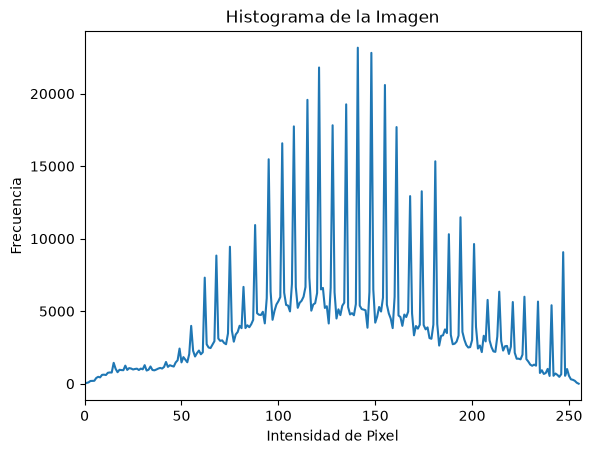

In [16]:
# prompt: i want hist fro array

import matplotlib.pyplot as plt

# ... (your existing code) ...

# Calculate histogram
hist = cv2.calcHist([imagen], [0], None, [256], [0, 256])

# Plot histogram
plt.figure()
plt.title("Histograma de la Imagen")
plt.xlabel("Intensidad de Pixel")
plt.ylabel("Frecuencia")
plt.plot(hist)
plt.xlim([0, 256])
plt.show()


In [17]:
imagen[:, 30]

array([127, 127, 127, ..., 148, 148, 148], shape=(1024,), dtype=uint8)